# **Bell State**

In this notebook, we construct and simulate a Bell state using a two-qubit quantum circuit.

We first introduce the mathematical idea behind the Bell state, then construct it using a Hadamard gate and a controlled-NOT (CNOT) gate. Finally, we simulate measurements of the state and compare the results with the theoretical probabilities.



## Theory

The Bell states are a set of two-qubit quantum states that are maximally entangled. In this notebook, we construct the Bell state

$$
|\Phi^+\rangle =
\frac{1}{\sqrt{2}}\left(|00\rangle + |11\rangle\right).
$$

We begin with the computational basis state

$$
|00\rangle.
$$

A Hadamard gate is first applied to qubit 0. The Hadamard gate transforms the state $|0\rangle$ into an equal superposition:

$$
H|0\rangle =
\frac{|0\rangle + |1\rangle}{\sqrt{2}}.
$$

Therefore,

$$
|00\rangle
\rightarrow
\frac{|00\rangle + |10\rangle}{\sqrt{2}}.
$$

Next, a controlled-NOT (CNOT) gate is applied, with qubit 0 as the control and qubit 1 as the target. The CNOT flips the target qubit when the control qubit is in the state $|1\rangle$:

$$
|00\rangle \rightarrow |00\rangle,
\qquad
|10\rangle \rightarrow |11\rangle.
$$

The final state is therefore

$$
|\Phi^+\rangle =
\frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

## Measurement

When the Bell state is measured in the computational basis, the two qubits are perfectly correlated.

The theoretical probabilities are

$$
P(00) = P(11) = \frac{1}{2},
$$

while

$$
P(01) = P(10) = 0.
$$

Therefore, an ideal simulation should produce only the outcomes `00` and `11`, with approximately equal frequencies.

Since the simulation uses a finite number of measurements, the observed frequencies will not necessarily be exactly $50\%$. Instead, they should fluctuate around the theoretical probabilities.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


# Create a two-qubit circuit with two classical bits for measurement.
qc = QuantumCircuit(2, 2)

# Create a superposition on qubit 0.
qc.h(0)

# Entangle the two qubits using a CNOT gate.
qc.cx(0, 1)

# Measure both qubits.
qc.measure([0, 1], [0, 1])

print(qc.draw())

     ┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1 


In [2]:
# Simulate the circuit 1000 times.
simulator = AerSimulator()
result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()
print(counts)

{'00': 493, '11': 507}


## Results

The circuit was simulated for 1000 shots. The measured outcomes were:

| Outcome | Counts | Measured probability |
|:-------:|-------:|:--------------------:|
| `00` | 486 | 48.6% |
| `11` | 514 | 51.4% |
| `01` | 0 | 0.0% |
| `10` | 0 | 0.0% |

For the Bell state

$$
|\Phi^+\rangle =
\frac{|00\rangle + |11\rangle}{\sqrt{2}},
$$

the theoretical probabilities are

$$
P(00) = P(11) = 50\%,
$$

with

$$
P(01) = P(10) = 0\%.
$$

The simulation therefore gives results close to the theoretical prediction. The measured probability of `00` is 1.4 percentage points below the theoretical value, while the probability of `11` is 1.4 percentage points above it.

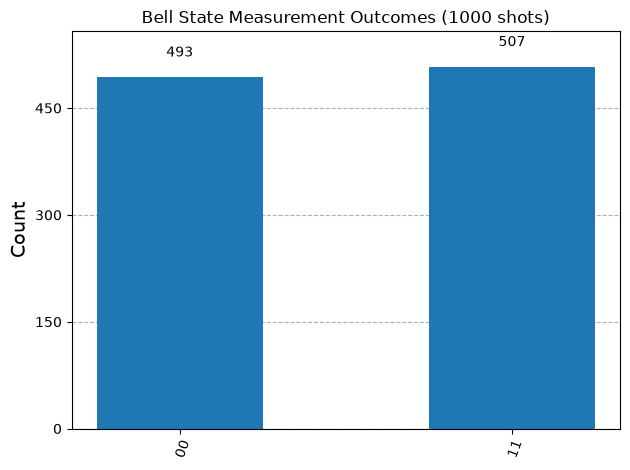

In [3]:
fig = plot_histogram(
    counts,
    title="Bell State Measurement Outcomes (1000 shots)"
)

fig.savefig(
    "../assets/bell_state_histogram.png",
    dpi=200,
    bbox_inches="tight"
)

display(fig)

## Discussion

The simulation agrees closely with the theoretical behaviour of the Bell state. The outcomes `00` and `11` occurred with probabilities of 48.6% and 51.4%, respectively, compared with the theoretical value of 50% for each outcome.

The outcomes `01` and `10` did not occur, as expected for the state

$$
|\Phi^+\rangle =
\frac{|00\rangle + |11\rangle}{\sqrt{2}}.
$$

The small difference between the measured and theoretical probabilities is expected because the simulation uses a finite number of shots. Each measurement is a probabilistic sample, so repeated simulations will generally produce slightly different counts.

The results also demonstrate the correlation between the two qubits. Whenever the first qubit is measured as $0$, the second qubit is also measured as $0$, and similarly for the outcome $1$. This correlation is a consequence of the entanglement in the Bell state.

## Conclusion

A Bell state was successfully constructed using a Hadamard gate followed by a controlled-NOT gate.

The 1000-shot simulation produced `00` and `11` with probabilities of 48.6% and 51.4%, respectively. These results are close to the theoretical prediction of 50% for each outcome, while `01` and `10` did not occur.

The simulation therefore confirms the expected measurement behaviour of the Bell state and demonstrates the strong correlation between the two qubits.